In [1]:
import pandas as pd
from Bio import SeqIO
import sys
import os
from ast import literal_eval
import numpy as np

import pybedtools
from pybedtools import BedTool


#For plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#For statistics
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import itertools

import re
from Bio import SeqIO
import ast # for safe eveal, for parsing some of the data
import math
os.chdir('/home/labs/davidgo/Collaboration/backup/MPRA_QC_pipeline/QC_analysis/scripts')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
const.set_plot_style()
import matplotlib.ticker as mtick

os.chdir('/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures')

output_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/fig_library_and_QC/'

/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


# Parameters

In [41]:
# Use CPM normalization?
cpm=True

# Use log scale in visualization?
logScale=False

min_DNA_counts = 0

# Figure 1 - hMPRA validation

### import and process all libraries

### Load annotations

In [42]:
diff_activity = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', 
                     header=0)
diff_activity = diff_activity.drop_duplicates(subset=["oligo"], keep = "first") #There are several HH oligos which are duplicated
diff_activity = diff_activity[#~(diff_activity['orientation_fix']=='fixed_in_L4')&
                           ~(diff_activity['oligo'].str.contains('SCREEN_EH'))&
                          ~(diff_activity['oligo'].str.contains('hh.missing.oligos')) ]



# create BED of diff_activity
diff_activity_bed_df = diff_activity[["chromosome","start","end","oligo"]]
diff_activity_bed_df.loc[:,"start"] = diff_activity_bed_df["start"].map(int) # already zero-based - Make sure with Simon!!
diff_activity_bed_df.loc[:,"end"] = diff_activity_bed_df["end"].map(int)
annotations_bed_df=diff_activity_bed_df.sort_values(['chromosome','start'], ascending = [True, True])
annotations_be = pybedtools.BedTool.from_dataframe(diff_activity_bed_df)

/tmp/ipykernel_958562/3021800644.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  diff_activity = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv',


In [43]:
diff_activity['minimum_DNA_counts'] = (
    diff_activity[['DNA_counts_raw_ancestral', 'DNA_counts_raw_derived']]
    .min(axis=1)
)

In [44]:

# thresholds you want
thresholds = [0, 10, 20, 50, 100,150,500]

# container for the frequency tables
freq_list = []

for t in thresholds:
    df_sub = diff_activity[diff_activity["minimum_DNA_counts"] >= t]

    # count True, False, NaN
    counts = df_sub["differential_activity"].value_counts(dropna=False)

    # ensure all categories exist
    freq_list.append({
        "threshold": t,
        "True": counts.get(True, 0),
        "False": counts.get(False, 0),
        "NaN": counts.get(np.nan, 0)
    })

freq_df = pd.DataFrame(freq_list)
freq_df


,threshold,True,False,NaN
0,0,15077,50499,289976
1,10,14634,46734,278689
2,20,14223,43584,273817
3,50,13411,38838,262217
4,100,12664,35087,246311
5,150,12049,32408,230417
6,500,8474,19057,137349


<Figure size 1000x600 with 0 Axes>

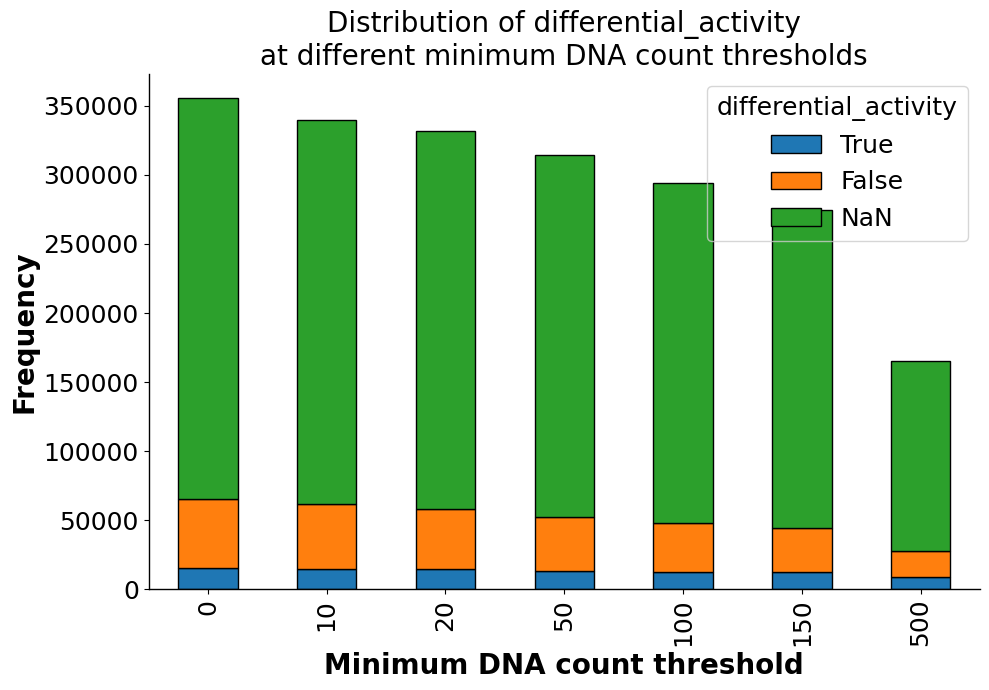

In [45]:
# set index for easy plotting
plot_df = freq_df.set_index("threshold")

plt.figure(figsize=(10,6))

# stacked bar chart
plot_df[["True","False","NaN"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10,7),
    edgecolor="black"
)

plt.xlabel("Minimum DNA count threshold")
plt.ylabel("Frequency")
plt.title("Distribution of differential_activity\nat different minimum DNA count thresholds")
plt.legend(title="differential_activity")
plt.tight_layout()
plt.show()


## Filter based on DNA counts

In [46]:
# 1. Create a new df which is a subset of the original
cols_to_keep = [
    'logFC_derived_vs_ancestral',
    'differential_activity_fdr',
    'differential_activity',
    'activity_ancestral',
    'activity_derived',
    'DNA_counts_raw_ancestral',
    'DNA_counts_raw_derived'
]

volcano_df = diff_activity[cols_to_keep].copy()

volcano_df['minimum_DNA_counts'] = (
    volcano_df[['DNA_counts_raw_ancestral', 'DNA_counts_raw_derived']]
    .min(axis=1)
)


# 2. Filter out all non active oligos
print(f' Active cCREs: {len(volcano_df)}')

eps = 1e-300
volcano_df['minus_log10_fdr'] = -np.log10(volcano_df['differential_activity_fdr'] + eps)

#volcano_df = volcano_df[(volcano_df['activity_ancestral']=='active')
#                        &(volcano_df['activity_derived']=='active')]

print(len(volcano_df))

# Optional: compute -log10(FDR) (add tiny epsilon to avoid log10(0))
volcano_df['minus_log10_fdr'] = -np.log10(volcano_df['differential_activity_fdr'])


minus_log10_fdr_max = 50   # X: max allowed FDR
lfc_max = 2.5    # Y: max allowed |logFC|

volcano_df = volcano_df[
    (volcano_df['minus_log10_fdr'] <= minus_log10_fdr_max) &
    (volcano_df['logFC_derived_vs_ancestral'].abs() <= lfc_max)
].copy()


 Active cCREs: 355891
355891


/home/labs/davidgo/nadavmi/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/tmp/ipykernel_958562/4262710465.py:5: RuntimeWarning: divide by zero encountered in log2
  z = np.log2(volcano_df['minimum_DNA_counts'].values)


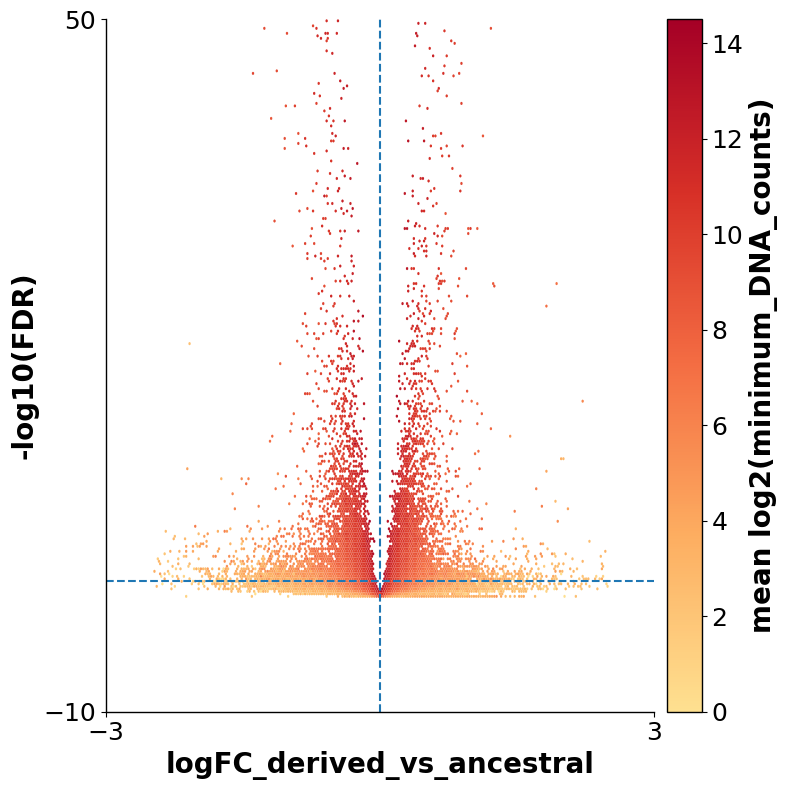

In [47]:
fig, ax = plt.subplots()

x = volcano_df['logFC_derived_vs_ancestral'].values
y = volcano_df['minus_log10_fdr'].values
z = np.log2(volcano_df['minimum_DNA_counts'].values)

hb = ax.hexbin(
    x, y,
    C=z,                      # value to aggregate within each hex
    reduce_C_function=np.mean, # or np.median
    gridsize=200,             # <-- higher = higher resolution (try 150–400)
    mincnt=1,                 # only draw hexbins with >=1 point
    cmap=custom_cmap_bolder,
    linewidths=0,
)

# Threshold lines
fdr_thresh = 0.05
ax.axhline(-np.log10(fdr_thresh), linestyle='--')
ax.axvline(0, linestyle='--')

ax.set_xlabel('logFC_derived_vs_ancestral')
ax.set_ylabel('-log10(FDR)')
ax.set_ylim(-5, 50)

cbar = plt.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label('mean log2(minimum_DNA_counts)')

xticks = plt.xticks()[0]
yticks = plt.yticks()[0]
plt.xticks([xticks[0], xticks[-1]])
plt.yticks([yticks[0], yticks[-1]])

plt.tight_layout()
const.save_fig(plt, 'diff_activity_volcano_hexbin_by_min_dna_counts', output_path)
plt.show()


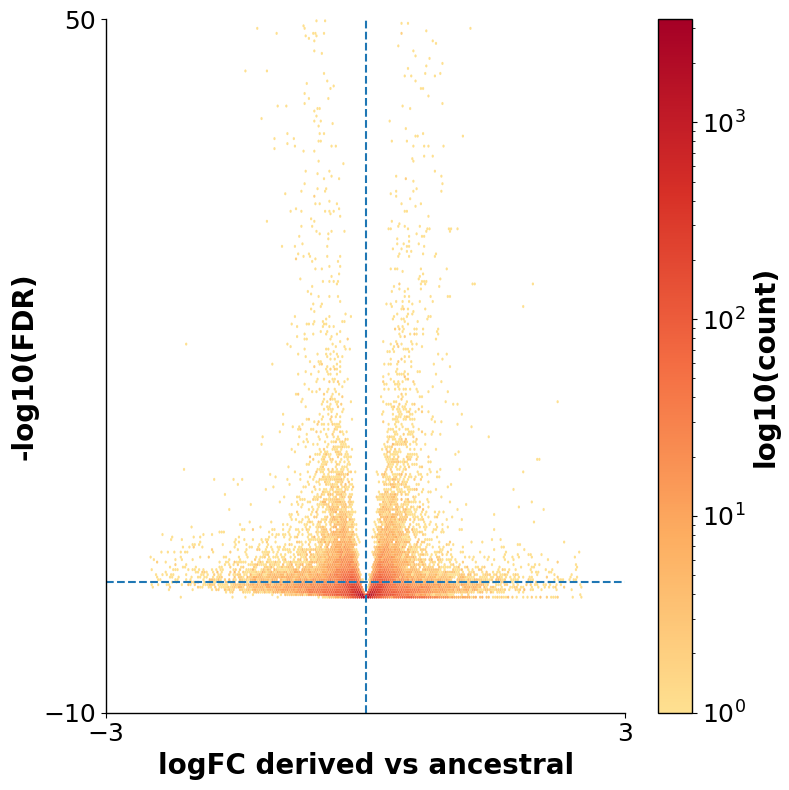

In [48]:
fig, ax = plt.subplots()

# X/Y for volcano
x = volcano_df['logFC_derived_vs_ancestral'].values
y = volcano_df['minus_log10_fdr'].values

# Hexbin density
hb = ax.hexbin(
    x, y,
    gridsize=200,             # adjust for coarser/finer grid
    cmap=custom_cmap_bolder,  # your existing cmap
    mincnt=1,                 # only show hexes with at least 1 point
    bins='log',                # log-scale colors by count
    linewidths=0
)

# Threshold lines
fdr_thresh = 0.05
ax.axhline(-np.log10(fdr_thresh), linestyle='--')
ax.axvline(0, linestyle='--')

ax.set_xlabel('logFC derived vs ancestral')
ax.set_ylabel('-log10(FDR)')
ax.set_ylim(-5, 50)

# Optional colorbar for density
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('log10(count)')

xticks = plt.xticks()[0]
yticks = plt.yticks()[0]
plt.xticks([xticks[0], xticks[-1]])
plt.yticks([yticks[0], yticks[-1]])

plt.tight_layout()

const.save_fig(plt, 'full_diff_activity_hexbin_by_density', output_path)

plt.show()


In [8]:
print(f"cCRE counts before filtering for minimum {min_DNA_counts} DNA counts in ancestral and derived (at least 5 in each): {len(diff_activity)}")
diff_activity = diff_activity[(diff_activity['DNA_counts_raw_derived']>min_DNA_counts) &
                               (diff_activity['DNA_counts_raw_ancestral']>min_DNA_counts)]
print(f"cCRE counts after filtering for minimum {min_DNA_counts} DNA counts in ancestral and derived (at least 5 in each): {len(diff_activity)}")


cCRE counts before filtering for minimum 50 DNA counts in ancestral and derived (at least 5 in each): 355891
cCRE counts after filtering for minimum 50 DNA counts in ancestral and derived (at least 5 in each): 313358


In [9]:
# 1. Create a new df which is a subset of the original
cols_to_keep = [
    'logFC_derived_vs_ancestral',
    'differential_activity_fdr',
    'differential_activity',
    'activity_ancestral',
    'activity_derived',
    'DNA_counts_raw_ancestral',
    'DNA_counts_raw_derived'
]

volcano_df = diff_activity[cols_to_keep].copy()

volcano_df['minimum_DNA_counts'] = (
    volcano_df[['DNA_counts_raw_ancestral', 'DNA_counts_raw_derived']]
    .min(axis=1)
)


# 2. Filter out all non active oligos
print(f' Active cCREs: {len(volcano_df)}')

eps = 1e-300
volcano_df['minus_log10_fdr'] = -np.log10(volcano_df['differential_activity_fdr'] + eps)

#volcano_df = volcano_df[(volcano_df['activity_ancestral']=='active')
#                        &(volcano_df['activity_derived']=='active')]

print(len(volcano_df))

# Optional: compute -log10(FDR) (add tiny epsilon to avoid log10(0))
volcano_df['minus_log10_fdr'] = -np.log10(volcano_df['differential_activity_fdr'])


minus_log10_fdr_max = 50   # X: max allowed FDR
lfc_max = 2.5    # Y: max allowed |logFC|

volcano_df = volcano_df[
    (volcano_df['minus_log10_fdr'] <= minus_log10_fdr_max) &
    (volcano_df['logFC_derived_vs_ancestral'].abs() <= lfc_max)
].copy()


 Active cCREs: 313358
313358


/home/labs/davidgo/nadavmi/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


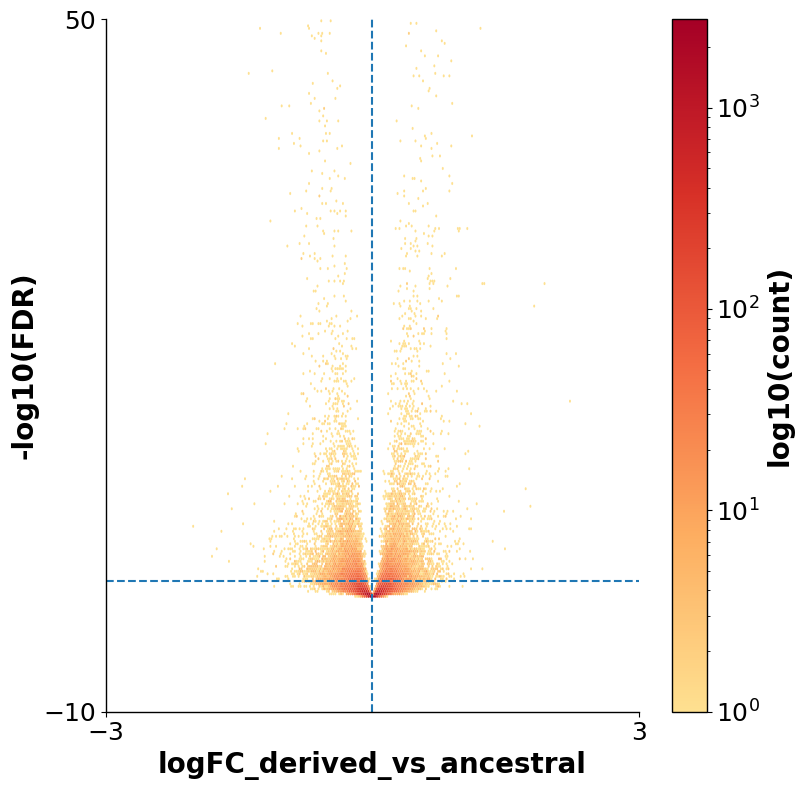

In [32]:
fig, ax = plt.subplots()

# X/Y for volcano
x = volcano_df['logFC_derived_vs_ancestral'].values
y = volcano_df['minus_log10_fdr'].values

# Hexbin density
hb = ax.hexbin(
    x, y,
    gridsize=200,             # adjust for coarser/finer grid
    cmap=custom_cmap_bolder,  # your existing cmap
    mincnt=1,                 # only show hexes with at least 1 point
    bins='log',                # log-scale colors by count
    linewidths=0
)

# Threshold lines
fdr_thresh = 0.05
ax.axhline(-np.log10(fdr_thresh), linestyle='--')
ax.axvline(0, linestyle='--')

ax.set_xlabel('logFC_derived_vs_ancestral')
ax.set_ylabel('-log10(FDR)')
ax.set_ylim(-5, 50)

xticks = plt.xticks()[0]
yticks = plt.yticks()[0]
plt.xticks([xticks[0], xticks[-1]])
plt.yticks([yticks[0], yticks[-1]])

plt.tight_layout()

const.save_fig(plt, 'filtered_50_diff_activity_hexbin_by_density', output_path)

# Optional colorbar for density
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('log10(count)')

const.save_fig(plt, 'filtered_50_diff_activity_hexbin_by_density_w_bar', output_path)


plt.show()


# Validatio of differential expression

In [11]:
libraries = [
    #"L3a3",
     "L1a1", "L1a2", "L1a3",
     "L2a1", "L2a2", "L2a3",
     "L3a1", "L3a2", "L3a3",
     "L4a1",
]

base_dir = "/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes"
rel_path = "output/mpranalyze_comparative/posctrl/mpranalyze_comp_res_filter_sorted.txt"

dfs = []
percents = []

for lib in libraries:
    positive_controls_dir = os.path.join(base_dir, lib, rel_path)
    df = pd.read_csv(positive_controls_dir, sep="\t")
    df["library"] = lib
    print(lib)

    successful_controls = (df["fdr"] < 0.05).sum()
    total_controls = len(df)

    pct = (successful_controls / total_controls) * 100 if total_controls else float("nan")
    percents.append(pct)

    print(f"{pct:.2f}%")
    dfs.append(df)

positive_controls = pd.concat(dfs, ignore_index=True)

avg_pct = sum(percents) / len(percents)
print(f"\nAverage across libraries: {avg_pct:.2f}%")



L1a1
29.29%
L1a2
36.00%
L1a3
37.00%
L2a1
50.51%
L2a2
35.05%
L2a3
42.11%
L3a1
33.67%
L3a2
52.58%
L3a3
32.89%
L4a1
9.28%

Average across libraries: 35.84%


In [12]:
print(sum(positive_controls['fdr']<0.05))
print(len(positive_controls))

442
1256


/home/labs/davidgo/nadavmi/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


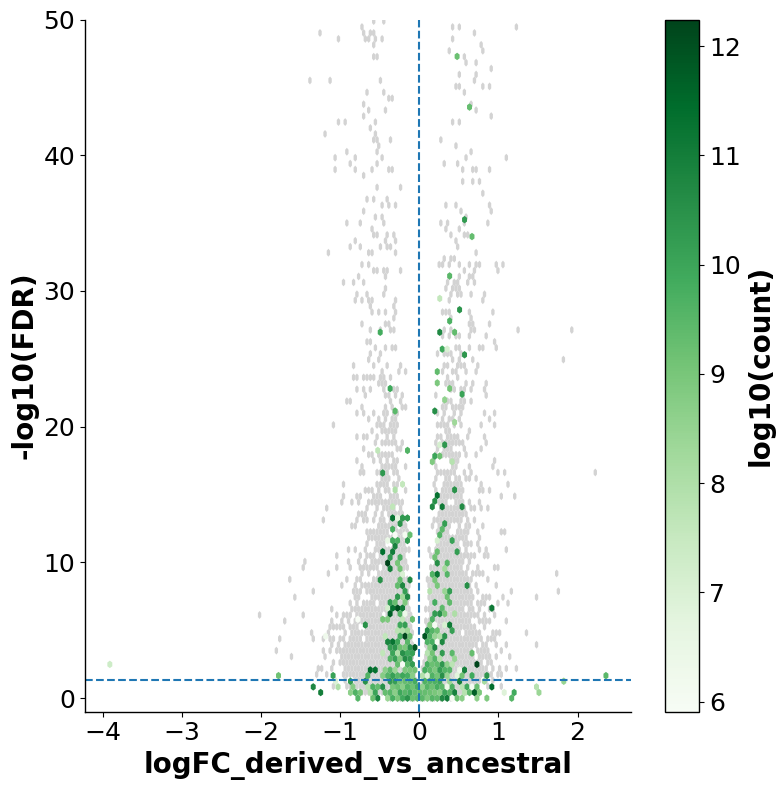

In [39]:
fig, ax = plt.subplots()

# X/Y for volcano
x = volcano_df['logFC_derived_vs_ancestral'].values
y = volcano_df['minus_log10_fdr'].values
z = np.log2(volcano_df['minimum_DNA_counts'].values)
# Hexbin density

hb = ax.hexbin(
    x, y,
    gridsize=100,
    mincnt=1,
    linewidths=0,
    edgecolors="none",
)

# force uniform styling (overrides colormap behavior)
hb.set_array(None)              # <-- this is the key if it's still colored
hb.set_facecolor("lightgray")
hb.set_edgecolor("none")
hb.set_alpha(1)


# hb = ax.scatter(
#     x, y,
#     c='lightgray',
#     alpha = 1,           
#     cmap=custom_cmap_bolder,  # your existing cmap
# )

positive_controls["minus_log10_fdr"] = -np.log10(positive_controls["fdr"].astype(float))
positive_controls_capped = positive_controls[positive_controls['minus_log10_fdr']<=50]

hb = ax.hexbin(
    positive_controls_capped["logFC"].values,
    positive_controls_capped["minus_log10_fdr"].values,
    C=z,                      # value to aggregate within each hex
    reduce_C_function=np.mean, # or np.median
    gridsize=100,             # <-- higher = higher resolution (try 150–400)
    mincnt=1,                 # only draw hexbins with >=1 point
    cmap="Greens",
    linewidths=0,
)

# Add positive controls for differential expression
# ax.scatter(
#     positive_controls["logFC"].values,
#     positive_controls["minus_log10_fdr"].values,
#     marker="o",
#     s=45,
#     c = 'green',
#     edgecolors=None,
#     linewidths=0.6,
#     alpha=1,
#     label="Positive controls"
# )



# Threshold lines
fdr_thresh = 0.05
ax.axhline(-np.log10(fdr_thresh), linestyle='--')
ax.axvline(0, linestyle='--')

ax.set_xlabel('logFC_derived_vs_ancestral')
ax.set_ylabel('-log10(FDR)')
ax.set_ylim(-1, 50)


const.save_fig(plt, 'diff_activity_controls_scatter_plot', output_path)

# Optional colorbar for density
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('log10(count)')

const.save_fig(plt, 'diff_activity_controls_scatter_plot_w_bar', output_path)


plt.tight_layout()
plt.show()


In [ ]:
hb = ax.scatter(
    x, y,
    c=z,
    alpha = 0.1,           
    cmap=custom_cmap_bolder,  # your existing cmap
)

In [5]:
positive_controls

,statistic,pval,fdr,df.test,df.dna,df.rna.full,df.rna.red,logFC
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq119140_a2_L3,12.572416,3.914821e-04,3.914821e-04,1,2742,3,2,-0.056124
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq119170_a2_L3,60.469036,7.474502e-15,7.474502e-15,1,1629,3,2,0.137572
PosCtrl_diff_ESCs+Osteoblasts+NPCs_Weiss_seq96982_a2_L3,384.461352,1.329442e-85,1.329442e-85,1,2074,3,2,0.365860
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq44930_a2_L3,50.313547,1.310418e-12,1.310418e-12,1,1374,3,2,-0.162512
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq14238_a2_L3,78.242098,9.115503e-19,9.115503e-19,1,1364,3,2,0.192552
...,...,...,...,...,...,...,...,...
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq95523_a2_L3,0.099281,7.526939e-01,8.938240e-01,1,12,3,2,0.106995
PosCtrl_diff_Osteoblasts_Weiss_seq311144_a2_L3,2.354338,1.249349e-01,2.703396e-01,1,8,3,2,1.079679
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq697_a2_L3,3.851711,4.969526e-02,1.888420e-01,1,6,3,2,-1.023802
PosCtrl_diff_ESCs+NPCs_Weiss_seq47294_a2_L3,0.625695,4.289387e-01,7.260150e-01,1,3,3,2,0.505772


In [24]:
# List of libraries
libraries = ["L3a2"
    #"L1a1", "L1a2", "L1a3",
    #"L2a1", "L2a2", "L2a3",
    #"L3a1", "L3a2", "L3a3",
    #"L4a1"
]

base_dir = r"/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes"

dfs = []

for lib in libraries:
    csv_path = os.path.join(
        base_dir,
        lib,
        "output",
        "activity_after_filter",
        "comb_df_adjusted_fdr.csv"
    )

    # Read CSV
    df = pd.read_csv(csv_path)

    # Keep only rows where "oligo" contains "ctrl"
    df_ctrl = df[
    df["oligo"].str.contains("Ctrl", na=False, case=False) |
    df["oligo"].str.contains("scramble", na=False, case=False)
        ].copy()
    
    # Optional: add a column to remember which library it came from
    df_ctrl["library"] = lib

    dfs.append(df_ctrl)

# Combine all control oligos from all libraries into one df
all_ctrl_oligos = pd.concat(dfs, ignore_index=True)


,oligo,RNA_chondrocytes_rep1,RNA_chondrocytes_rep2,RNA_chondrocytes_rep3,DNA_chondrocytes_rep1,DNA_chondrocytes_rep2,DNA_chondrocytes_rep3,statistic,control,zscore,...,max_UMI_RNA_rep1,max_UMI_DNA_rep1,max_UMI_RNA_rep2,max_UMI_DNA_rep2,max_UMI_RNA_rep3,max_UMI_DNA_rep3,fdr.mad_adjusted,activity_adjusted,input_comparative,library
0,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[8.0, 19.0, 0.0, 2.0, 6.0, 17.0, 13.0, 46.0, 4...","[3.0, 35.0, 0.0, 11.0, 7.0, 5.0, 19.0, 3.0, 8....","[1.0, 9.0, 0.0, 7.0, 3.0, 35.0, 9.0, 5.0, 4.0,...","[1.0, 5.0, 0.0, 4.0, 4.0, 0.0, 3.0, 1.0, 0.0, ...","[2.0, 4.0, 0.0, 4.0, 1.0, 0.0, 2.0, 1.0, 0.0, ...","[0.0, 2.0, 0.0, 3.0, 0.0, 0.0, 5.0, 0.0, 0.0, ...",3.070469,False,1.307015,...,46.0,15.0,35.0,11.0,48.0,7.0,1.0,NaN,no,L3a2
1,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[40.0, 81.0, 16.0, 134.0, 4.0, 10.0, 18.0, 166...","[28.0, 27.0, 26.0, 78.0, 5.0, 11.0, 28.0, 135....","[16.0, 3.0, 11.0, 60.0, 78.0, 103.0, 40.0, 126...","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 15.0, 0.0,...","[9.0, 0.0, 2.0, 3.0, 4.0, 0.0, 1.0, 6.0, 1.0, ...","[0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 5.0, ...",12.597358,False,14.095429,...,290.0,18.0,228.0,22.0,314.0,16.0,1.0,NaN,no,L3a2
2,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[4.0, 7.0, 3.0, 17.0, 14.0, 6.0, 17.0, 10.0, 3...","[1.0, 33.0, 27.0, 28.0, 2.0, 12.0, 0.0, 8.0, 8...","[4.0, 7.0, 7.0, 25.0, 2.0, 7.0, 40.0, 7.0, 3.0...","[2.0, 2.0, 0.0, 8.0, 8.0, 0.0, 5.0, 1.0, 0.0, ...","[2.0, 6.0, 0.0, 2.0, 0.0, 9.0, 0.0, 2.0, 6.0, ...","[4.0, 0.0, 0.0, 5.0, 1.0, 7.0, 1.0, 2.0, 0.0, ...",2.829092,False,0.983003,...,129.0,17.0,75.0,24.0,124.0,18.0,1.0,NaN,no,L3a2
3,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[2.0, 11.0, 5.0, 0.0, 5.0, 9.0, 11.0, 3.0, 0.0...","[3.0, 10.0, 1.0, 0.0, 1.0, 8.0, 7.0, 0.0, 13.0...","[8.0, 17.0, 19.0, 1.0, 6.0, 12.0, 4.0, 3.0, 6....","[0.0, 4.0, 2.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...","[0.0, 2.0, 0.0, 0.0, 1.0, 4.0, 3.0, 0.0, 1.0, ...","[0.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, ...",2.108742,False,0.016041,...,73.0,18.0,97.0,26.0,66.0,21.0,1.0,NaN,no,L3a2
4,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[9.0, 0.0, 12.0, 18.0, 18.0, 9.0, 7.0, 0.0, 28...","[7.0, 2.0, 18.0, 32.0, 13.0, 6.0, 2.0, 0.0, 7....","[6.0, 8.0, 30.0, 0.0, 28.0, 4.0, 8.0, 0.0, 21....","[6.0, 0.0, 7.0, 4.0, 8.0, 5.0, 3.0, 0.0, 3.0, ...","[0.0, 2.0, 6.0, 1.0, 8.0, 0.0, 0.0, 0.0, 6.0, ...","[1.0, 0.0, 3.0, 0.0, 7.0, 2.0, 0.0, 0.0, 1.0, ...",3.223658,False,1.512648,...,68.0,18.0,140.0,21.0,100.0,14.0,1.0,NaN,no,L3a2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,scrambled_control_796_a2_L3,"[10.0, 7.0, 9.0, 6.0, 10.0, 12.0, 2.0, 17.0, 8...","[8.0, 4.0, 6.0, 8.0, 9.0, 5.0, 1.0, 13.0, 7.0,...","[20.0, 4.0, 4.0, 4.0, 8.0, 12.0, 4.0, 7.0, 9.0...","[0.0, 4.0, 3.0, 1.0, 5.0, 1.0, 2.0, 4.0, 0.0, ...","[3.0, 1.0, 0.0, 3.0, 2.0, 2.0, 0.0, 6.0, 2.0, ...","[12.0, 0.0, 0.0, 1.0, 3.0, 0.0, 0.0, 5.0, 0.0,...",1.913441,True,-0.246121,...,21.0,10.0,28.0,14.0,22.0,14.0,1.0,NaN,no,L3a2
657,scrambled_control_797_a2_L3,"[0.0, 6.0, 0.0, 2.0, 2.0, 7.0, 0.0, 0.0, 5.0, ...","[2.0, 4.0, 6.0, 0.0, 1.0, 1.0, 0.0, 1.0, 6.0, ...","[1.0, 4.0, 1.0, 1.0, 4.0, 1.0, 0.0, 4.0, 2.0, ...","[0.0, 0.0, 0.0, 4.0, 2.0, 6.0, 0.0, 0.0, 0.0, ...","[3.0, 0.0, 2.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 2.0, 1.0, 0.0, 0.0, 1.0, 0.0, ...",1.805970,True,-0.390386,...,15.0,13.0,21.0,15.0,37.0,10.0,1.0,NaN,no,L3a2
658,scrambled_control_798_a2_L3,"[8.0, 6.0]","[3.0, 2.0]","[0.0, 0.0]","[0.0, 1.0]","[0.0, 0.0]","[0.0, 0.0]",4.752586,True,3.565004,...,8.0,1.0,3.0,0.0,0.0,0.0,1.0,NaN,no,L3a2
659,scrambled_control_799_a2_L3,"[0.0, 2.0, 6.0, 5.0, 23.0, 24.0, 7.0, 19.0, 0....","[1.0, 3.0, 8.0, 8.0, 14.0, 12.0, 6.0, 6.0, 0.0...","[5.0, 2.0, 9.0, 3.0, 11.0, 6.0, 5.0, 14.0, 2.0...","[1.0, 0.0, 3.0, 3.0, 7.0, 4.0, 5.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 3.0, 8.0, 14.0, 1.0, 2.0, 0.0,...","[0.0, 0.0, 2.0, 1.0, 9.0, 0.0, 2.0, 2.0, 2.0, ...",2.292884,True,0.263224,...

In [ ]:
control_types = [
    "NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs",
    "NegCtrl_non_SCREEN",
    "scrambled_control",
    "PosCtrl_diff_ESCs_Weiss_seq11687_derived_a1_L4",
    "NegCtrl_not_active_ESCs+Osteoblasts+NPCs",
    "PosCtrl_diff_ESCs+Osteoblasts+NPCs",
    "PosCtrl_chondrocyte_active",
    "PosCtrl_diff_NPCs_Weiss",
    "PosCtrl_diff_ESCs+NPCs",
    "PosCtrl_diff_ESCs_Weiss",
    "PosCtrl_diff_ESCs+Osteoblasts",
    "PosCtrl_diff_Osteoblasts+NPCs",
    "PosCtrl_diff_Osteoblasts",
    "PosCtrl_neuron_active",
    "PosCtrl_osteoblast_active",
]

ctrl_dict = {}

for ctype in control_types:
    mask = all_ctrl_oligos["oligo"].str.contains(ctype, regex=False)
    ctrl_dict[ctype] = all_ctrl_oligos[mask].copy()

# Optional: if you want a df of any remaining controls that didn't match:
unmatched_mask = ~pd.concat(
    [all_ctrl_oligos["oligo"].str.contains(ct, na=False, regex=False) for ct in control_types],
    axis=1
).any(axis=1)

ctrl_dict["other_ctrls"] = all_ctrl_oligos[unmatched_mask].copy()

to_combine = [
    "PosCtrl_chondrocyte_active",
    "PosCtrl_osteoblast_active",
    "NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs"
]

ctrl_dict["all_activity_pos_ctrl"] = (
    pd.concat([ctrl_dict[k] for k in to_combine], ignore_index=True)
)

#Add the tested cCREs
# Add tested cCREs as a new entry in the control dictionary
# (here we only keep mad.score since that's what we plot)
ctrl_dict["tested_cCREs"] = full_activity_df[["mad.score"]]



,oligo,RNA_chondrocytes_rep1,RNA_chondrocytes_rep2,RNA_chondrocytes_rep3,DNA_chondrocytes_rep1,DNA_chondrocytes_rep2,DNA_chondrocytes_rep3,statistic,control,zscore,...,max_UMI_RNA_rep1,max_UMI_DNA_rep1,max_UMI_RNA_rep2,max_UMI_DNA_rep2,max_UMI_RNA_rep3,max_UMI_DNA_rep3,fdr.mad_adjusted,activity_adjusted,input_comparative,library
0,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[4.0, 0.0, 2.0, 0.0, 2.0, 7.0, 6.0, 0.0, 0.0, ...","[0.0, 4.0, 2.0, 0.0, 1.0, 5.0, 7.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 7.0, 6.0, 3.0, 2.0, ...","[0.0, 3.0, 0.0, 0.0, 0.0, 1.0, 7.0, 0.0, 0.0, ...","[0.0, 7.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 3.0, 7.0, 0.0, 0.0, ...",1.425600,False,0.404900,...,22.0,11.0,18.0,15.0,37.0,10.0,1.0,NaN,no,L1a1
1,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[29.0, 5.0, 31.0, 14.0, 17.0, 73.0, 16.0, 0.0,...","[11.0, 2.0, 17.0, 8.0, 7.0, 60.0, 41.0, 0.0, 0...","[62.0, 9.0, 19.0, 14.0, 64.0, 32.0, 40.0, 0.0,...","[0.0, 0.0, 3.0, 0.0, 0.0, 3.0, 0.0, 0.0, 3.0, ...","[3.0, 0.0, 0.0, 6.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 2.0, 7.0, 1.0, 4.0, 0.0, 0.0, ...",7.359414,False,17.445149,...,88.0,5.0,97.0,6.0,103.0,7.0,1.0,NaN,no,L1a1
2,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[15.0, 0.0, 14.0, 9.0, 7.0, 10.0, 6.0, 0.0, 11...","[37.0, 11.0, 5.0, 37.0, 0.0, 1.0, 5.0, 10.0, 1...","[20.0, 0.0, 6.0, 4.0, 12.0, 0.0, 31.0, 3.0, 6....","[5.0, 0.0, 3.0, 0.0, 0.0, 0.0, 10.0, 0.0, 1.0,...","[3.0, 0.0, 4.0, 3.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...","[5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, 0.0, 0.0, ...",2.207002,False,2.648866,...,62.0,18.0,122.0,14.0,55.0,14.0,1.0,NaN,no,L1a1
3,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[7.0, 3.0, 9.0, 3.0, 5.0, 10.0, 0.0, 6.0, 1.0,...","[3.0, 5.0, 2.0, 0.0, 5.0, 3.0, 4.0, 2.0, 0.0, ...","[5.0, 0.0, 0.0, 1.0, 14.0, 0.0, 4.0, 2.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 1.0, ...","[0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 5.0, 0.0, 0.0, 0.0, 0.0, ...",1.171234,False,-0.325569,...,19.0,20.0,21.0,14.0,23.0,12.0,1.0,NaN,no,L1a1
4,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,"[7.0, 6.0, 2.0, 10.0, 0.0, 5.0, 7.0, 0.0, 4.0,...","[5.0, 6.0, 5.0, 24.0, 0.0, 7.0, 6.0, 0.0, 3.0,...","[1.0, 17.0, 2.0, 6.0, 3.0, 6.0, 9.0, 0.0, 7.0,...","[0.0, 0.0, 0.0, 3.0, 11.0, 0.0, 4.0, 0.0, 0.0,...","[0.0, 1.0, 0.0, 6.0, 0.0, 0.0, 0.0, 0.0, 3.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 5.0, 0.0, 0.0, ...",1.738895,False,1.304593,...,20.0,16.0,38.0,14.0,39.0,17.0,1.0,NaN,no,L1a1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,scrambled_control_96_a1_L4,"[1.0, 0.0, 5.0, 1.0, 6.0, 0.0, 0.0, 0.0, 0.0, ...","[2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 3.0, 5.0, ...","[10.0, 0.0, 0.0, 0.0, 4.0, 7.0, 8.0, 11.0, 0.0...","[0.0, 0.0, 4.0, 0.0, 3.0, 7.0, 0.0, 0.0, 2.0, ...","[0.0, 5.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, ...",0.919186,True,-0.150869,...,17.0,24.0,9.0,10.0,12.0,12.0,1.0,NaN,no,L4a1
7146,scrambled_control_97_a1_L4,"[8.0, 0.0, 0.0, 0.0, 0.0, 8.0, 0.0, 0.0, 3.0, ...","[1.0, 0.0, 3.0, 6.0, 0.0, 4.0, 0.0, 3.0, 1.0, ...","[6.0, 4.0, 10.0, 0.0, 0.0, 0.0, 0.0, 4.0, 9.0,...","[5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, ...",0.939419,True,-0.121510,...,12.0,21.0,10.0,7.0,10.0,8.0,1.0,NaN,no,L4a1
7147,scrambled_control_98_a1_L4,"[0.0, 0.0, 11.0, 5.0, 0.0, 8.0, 2.0, 1.0, 0.0,...","[0.0, 0.0, 7.0, 0.0, 0.0, 4.0, 2.0, 1.0, 5.0, ...","[0.0, 3.0, 7.0, 0.0, 0.0, 5.0, 9.0, 3.0, 2.0, ...","[0.0, 0.0, 5.0, 2.0, 4.0, 0.0, 7.0, 5.0, 3.0, ...","[0.0, 0.0, 5.0, 0.0, 0.0, 0.0, 0.0, 7.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, ...",0.923664,True,-0.144371,...,13.0,30.0,13.0,7.0,15.0,27.0,1.0,NaN,no,L4a1
7148,scrambled_control_99_a1_L4,"[3.0, 0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 2.0, 0.0, 7.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[0.

## Correlation between libraries

In [2]:
controls_corr_dir = "/home/labs/davidgo/Collaboration/humanMPRA/additional/analyze_controls/chondrocytes/controls_df.csv"
ctrls_corr_df = pd.read_csv(controls_corr_dir)
ctrls_corr_df = ctrls_corr_df.loc[:, ~ctrls_corr_df.columns.str.contains("L4a2", na=False)]
alpha = ctrls_corr_df.filter(regex='alpha')

In [3]:
active_patterns = [
    "PosCtrl_chondrocyte_active",
    "PosCtrl_osteoblast_active",
    "NegCtrl_active_not_diff",
]

negative_patterns = [
    "scrambled_control",
    "NegCtrl_not_active",
    "NegCtrl_non_SCREEN",
]

oligos = ctrls_corr_df["oligo"].fillna("")

active_mask = pd.Series(False, index=ctrls_corr_df.index)
for p in active_patterns:
    active_mask |= oligos.str.contains(p, regex=False)

negative_mask = pd.Series(False, index=ctrls_corr_df.index)
for p in negative_patterns:
    negative_mask |= oligos.str.contains(p, regex=False)

active_ctrls_corr_df = ctrls_corr_df[active_mask].copy()
negative_ctrls_corr_df = ctrls_corr_df[negative_mask].copy()

positive_ctrls_alpha = active_ctrls_corr_df.filter(regex='alpha')
negative_ctrls_alpha = negative_ctrls_corr_df.filter(regex='alpha')

positive_ctrls_corr_alpha = positive_ctrls_alpha.corr()
negative_ctrls_corr_alpha = negative_ctrls_alpha.corr()

negative_ctrls_corrc_alpha = negative_ctrls_corr_alpha.round(2)
positive_ctrls_corr_alpha = positive_ctrls_corr_alpha.round(2)



In [5]:
active_ctrls_corr_df

,oligo,alpha_L1a1,fdr.mad_L1a1,ratio_log_rep_comb_L1a1,control_type_L1a1,activity_L1a1,alpha_L1a2,fdr.mad_L1a2,ratio_log_rep_comb_L1a2,control_type_L1a2,...,alpha_L3a3,fdr.mad_L3a3,ratio_log_rep_comb_L3a3,control_type_L3a3,activity_L3a3,alpha_L4a1,fdr.mad_L4a1,ratio_log_rep_comb_L4a1,control_type_L4a1,activity_L4a1
0,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,1.425600,4.917083e-01,-0.152549,NegCtrl_active_not_diff,non_active,2.659796,2.233840e-03,0.555029,NegCtrl_active_not_diff,...,2.207146,6.134976e-04,0.782832,NegCtrl_active_not_diff,active,1.462240,1.530600e-02,0.793545,NegCtrl_active_not_diff,active
1,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,7.359414,2.647942e-84,2.191706,NegCtrl_active_not_diff,active,9.616071,1.207466e-224,2.328477,NegCtrl_active_not_diff,...,8.425747,2.495205e-192,2.785662,NegCtrl_active_not_diff,active,2.885281,3.612001e-22,1.708160,NegCtrl_active_not_diff,active
2,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,2.207002,1.199385e-02,0.424608,NegCtrl_active_not_diff,active,2.546418,9.763155e-03,0.447470,NegCtrl_active_not_diff,...,1.736024,1.789306e-01,0.170841,NegCtrl_active_not_diff,non_active,1.385112,4.207712e-02,0.130724,NegCtrl_active_not_diff,active
3,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,1.171234,7.247526e-01,-0.284417,NegCtrl_active_not_diff,non_active,1.939529,5.453364e-01,0.135718,NegCtrl_active_not_diff,...,1.234193,9.292382e-01,-0.590108,NegCtrl_active_not_diff,non_active,0.674487,9.250328e-01,-0.928088,NegCtrl_active_not_diff,non_active
4,NegCtrl_active_not_diff_ESCs+Osteoblasts+NPCs_...,1.738895,2.217747e-01,0.330757,NegCtrl_active_not_diff,non_active,2.883684,6.270484e-05,0.647265,NegCtrl_active_not_diff,...,1.742889,1.695577e-01,0.054116,NegCtrl_active_not_diff,non_active,1.082327,5.143484e-01,-0.237303,NegCtrl_active_not_diff,non_active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1801,PosCtrl_osteoblast_active_Weiss_libB_seq6227_[...,1.795145,1.795670e-01,0.898595,PosCtrl_osteoblast_active,non_active,5.308570,1.430172e-45,1.500145,PosCtrl_osteoblast_active,...,4.967710,7.913133e-52,1.885262,PosCtrl_osteoblast_active,active,2.065019,3.688805e-08,1.163692,PosCtrl_osteoblast_active,active
1802,PosCtrl_osteoblast_active_Weiss_libB_seq70914_...,2.157767,1.851574e-02,0.669848,PosCtrl_osteoblast_active,active,5.595853,2.912004e-53,1.586234,PosCtrl_osteoblast_active,...,3.947721,1.713490e-27,1.520613,PosCtrl_osteoblast_active,active,NaN,NaN,NaN,NaN,NaN
1803,PosCtrl_osteoblast_active_Weiss_libB_seq85588_...,1.569193,3.623848e-01,0.084324,PosCtrl_osteoblast_active,non_active,2.059168,3.956947e-01,0.141327,PosCtrl_osteoblast_active,...,1.447069,7.826203e-01,-0.218456,PosCtrl_osteoblast_active,non_active,NaN,NaN,NaN,NaN,NaN
1804,PosCtrl_osteoblast_active_Weiss_libB_seq89083_...,1.194644,7.052446e-01,-0.322326,PosCtrl_osteoblast_active,non_active,4.330444,5.931220e-24,1.309473,PosCtrl_osteoblast_active,...,2.506838,2.226198e-06,1.000099,PosCtrl_osteoblast_active,active,NaN,NaN,NaN,NaN,NaN


In [6]:
output_path

'/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/fig_library_and_QC/'

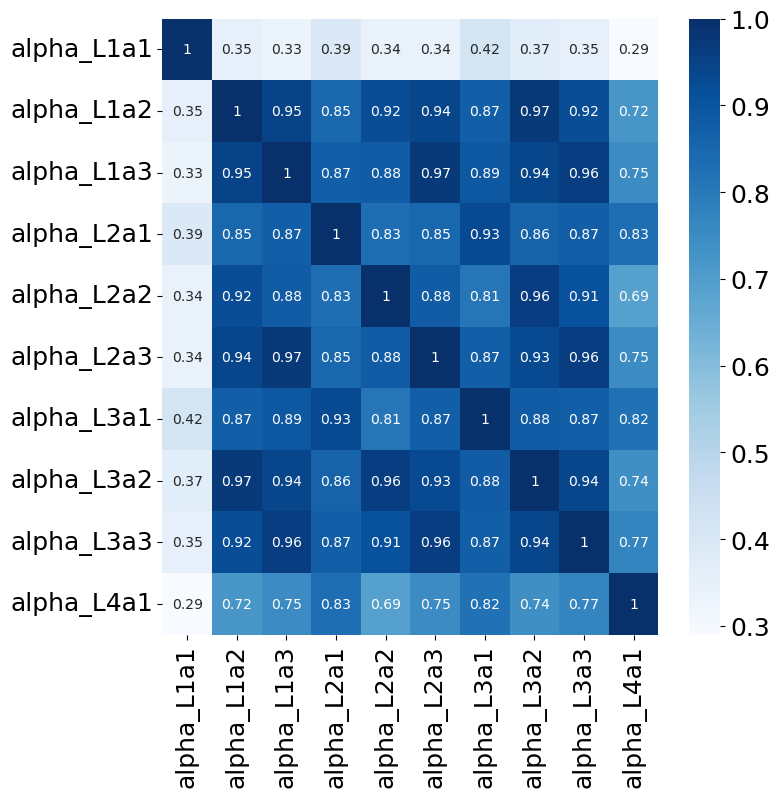

In [8]:
plt.clf()
sns.heatmap(positive_ctrls_corr_alpha, cmap="Blues", annot=True)
const.save_fig(plt, 'pos_ctrl_correlation_across_libraries', output_path)

plt.show()

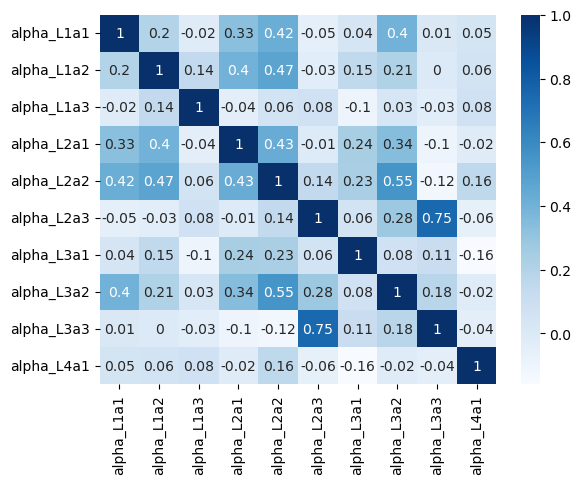

In [38]:
plt.clf()
sns.heatmap(negative_ctrls_corrc_alpha, cmap="Blues", annot=True)
plt.show()

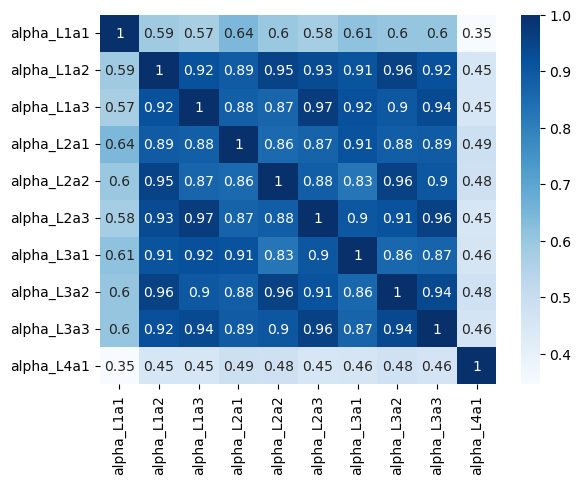

In [40]:
corr_alpha = alpha.corr()
plt.clf()
sns.heatmap(corr_alpha, cmap="Blues", annot=True)
plt.show()

# GC content in the library

In [7]:
# load library design

library = pd.read_excel(f'/home/labs/davidgo/Collaboration/humanMPRA_raw/sequences.xlsx', 
                    sheet_name = 'oligos',
                    #usecols=lambda x: x not in ["derived_seq_with_adapters", "ancestral_seq_with_adapters"],
                     header=0)

# filter for SCREEN oligos
print(f'rows before filtering for SCREEN: {len(library)}')
library = library[library['source'].str.contains('SCREEN')]
print(f'rows after filtering for SCREEN: {len(library)}')
print(f'oligo counts after filtering for SCREEN: {len(library)*2}')

# load L4 library design
library_L4 = pd.read_excel(
    "/home/labs/davidgo/Collaboration/humanMPRA_raw/L4/L4_v5.xlsx",
    sheet_name="test_oligos",
    #usecols=lambda x: x not in ["derived_sequence_with_adapters", "ancestral_seq_with_adapters"],
    header=0
)


rows before filtering for SCREEN: 355697
rows after filtering for SCREEN: 343503
oligo counts after filtering for SCREEN: 687006
oligo counts in L4: 51740
oligos fixed in L4a1 which I removed from the original library design:2971


In [13]:

#change derived_sequence_with_adapters name to derived_seq_with_adapters
library_L4 = library_L4.rename(columns={"derived_sequence_with_adapters": "derived_seq_with_adapters"})
library_L4 = library_L4.rename(columns={"ancestral_sequence_with_adapters": "ancestral_seq_with_adapters"})

# filter for SCREEN oligos in L4
library_L4_filtered = library_L4.copy()
library_L4_filtered = library_L4_filtered[(library_L4_filtered['adapter']=='a1')&
                                          (library_L4_filtered['name'].str.contains('SCREEN'))&
                                          (library_L4_filtered['class'].isin(['CGI.fix','promoter.orientation.fix']))]
print(f'oligo counts in L4: {len(library_L4_filtered)*2}')

# check how many of the oligos I removed from the original library design are now fixed in L4a1
fixed_variants = library_L4_filtered['variants_genomic']
fixed_oligos = sum(library['variants_genomic'].isin(fixed_variants))
print(f'oligos fixed in L4a1 which I removed from the original library design:{fixed_oligos}')

filtered_library = library[~library['variants_genomic'].isin(fixed_variants)]


# columns shared by both
common_cols = filtered_library.columns.intersection(library_L4_filtered.columns)

# concatenate, keeping only shared columns (aligned + same order)
final_oligos = pd.concat([library_L4_filtered[common_cols],filtered_library[common_cols]], ignore_index=True)

final_oligos = final_oligos.drop_duplicates(
    subset="variants_genomic",
    keep="first"
)



oligo counts in L4: 51740
oligos fixed in L4a1 which I removed from the original library design:2971


In [14]:

all_variants = (
    final_oligos["variants_genomic"]
      .dropna()
      .str.split(";")
      .explode()
      .tolist()
)
len(set(all_variants))



561410

## Calculate GC content

In [16]:
def GC_calc(seq):
    C = seq.count("C") + seq.count("c")
    G = seq.count("G") + seq.count("g")
    perc = (C + G) / len(seq)
    return perc

#make sequence capitalized
final_oligos['derived_seq_with_adapters'] = final_oligos['derived_seq_with_adapters'].str.upper()
final_oligos['ancestral_seq_with_adapters'] = final_oligos['ancestral_seq_with_adapters'].str.upper()

(array([1.58000e+02, 2.80200e+03, 1.78510e+04, 4.46030e+04, 8.96960e+04,
        1.02611e+05, 1.23412e+05, 1.03949e+05, 9.36420e+04, 5.84100e+04,
        3.46920e+04, 1.78180e+04, 7.50100e+03, 8.11400e+03, 8.34600e+03,
        8.57400e+03, 5.85400e+03, 3.73600e+03, 9.59000e+02, 7.60000e+01]),
 array([0.25333333, 0.2815    , 0.30966667, 0.33783333, 0.366     ,
        0.39416667, 0.42233333, 0.4505    , 0.47866667, 0.50683333,
        0.535     , 0.56316667, 0.59133333, 0.6195    , 0.64766667,
        0.67583333, 0.704     , 0.73216667, 0.76033333, 0.7885    ,
        0.81666667]),
 <BarContainer object of 20 artists>)

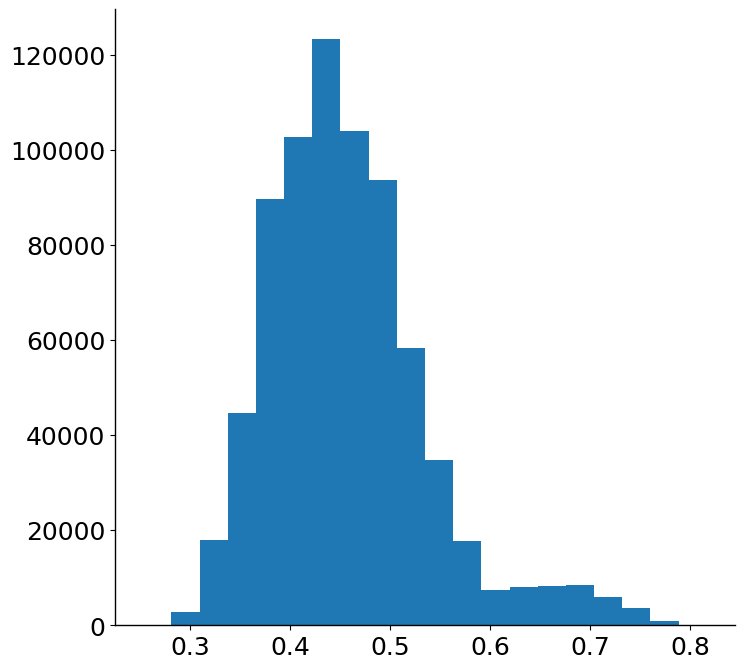

In [19]:
#create a new vector of GC ocntent in all sequences
final_oligos['GC_content_derived'] = final_oligos['derived_seq_with_adapters'].apply(GC_calc)
final_oligos['GC_content_ancestral'] = final_oligos['ancestral_seq_with_adapters'].apply(GC_calc)
GC_content = pd.concat([final_oligos['GC_content_derived'], final_oligos['GC_content_ancestral']], ignore_index=True)
plt.hist(GC_content, bins=20)

In [22]:
# read this fasta file: "\\data.wexac.weizmann.ac.il\davidgo\Collaboration\humanMPRA\oligo_fasta\L1L2L3L4a1.fasta"
fasta_path = "/home/labs/davidgo/Collaboration/humanMPRA/oligo_fasta/L1L2L3L4a1.fasta"
sequences = list(SeqIO.parse(fasta_path, "fasta")) 

def GC_calc(seq):
    C = seq.count("C") + seq.count("c")
    G = seq.count("G") + seq.count("g")
    perc = (C + G) / len(seq)
    return perc


In [28]:

# Create a dataframe with sequences and their GC content
gc_data = []
for seq in sequences:
    seq_str = str(seq.seq)
    gc_percent = GC_calc(seq_str)
    gc_data.append({
        'sequence_id': seq.id,
        'gc_content': gc_percent
    })
gc_df = pd.DataFrame(gc_data)


In [32]:
#read cCRE molecule counts
cCRE_association_counts_path = "/home/labs/davidgo/Collaboration/humanMPRA/neurons/combined_files/cCRE_association_counts.csv"
cCRE_association_counts = pd.read_csv(cCRE_association_counts_path)

In [34]:
# Merge gc_df with cCRE_association_counts on sequence_id and cCRE
final_counts_df = gc_df.merge(
    cCRE_association_counts,
    left_on='sequence_id',
    right_on='cCRE',
    how='inner'
)

# Rename gc_content to gc for easier reference
final_counts_df = final_counts_df.rename(columns={'gc_content': 'gc'})

In [35]:
final_counts_df

,sequence_id,gc,cCRE,association_count
0,seq_41884_chr1:1211358-1211627_SCREEN_ancestra...,0.503333,seq_41884_chr1:1211358-1211627_SCREEN_ancestra...,150
1,seq_28582_chr1:1330416-1330685_SCREEN_ancestra...,0.346667,seq_28582_chr1:1330416-1330685_SCREEN_ancestra...,2
2,seq_41298_chr1:1504938-1505207_SCREEN_ancestra...,0.526667,seq_41298_chr1:1504938-1505207_SCREEN_ancestra...,277
3,seq_26945_chr1:1509140-1509409_SCREEN_ancestra...,0.416667,seq_26945_chr1:1509140-1509409_SCREEN_ancestra...,152
4,seq_24882_chr1:1546642-1546911_SCREEN_ancestra...,0.523333,seq_24882_chr1:1546642-1546911_SCREEN_ancestra...,191
...,...,...,...,...
740415,PosCtrl_osteoblast_active_Weiss_libA_seq2965_[...,0.570370,PosCtrl_osteoblast_active_Weiss_libA_seq2965_[...,97
740416,PosCtrl_osteoblast_active_Weiss_libA_seq64089_...,0.600000,PosCtrl_osteoblast_active_Weiss_libA_seq64089_...,116
740417,PosCtrl_osteoblast_active_Weiss_libA_seq14218_...,0.640741,PosCtrl_osteoblast_active_Weiss_libA_seq14218_...,84
740418,PosCtrl_osteoblast_active_Weiss_libA_seq11467_...,0.670370,PosCtrl_osteoblast_active_Weiss_libA_seq11467_...,106


In [50]:
def PCR_bias_GC_plot(final_counts_df):
    gc_bins = pd.cut(final_counts_df["gc"], bins=np.arange(0, 1.01, 0.05), duplicates="drop")
    final_counts_df["gc_bin"] = gc_bins
    bin_sizes = final_counts_df.reset_index().groupby("gc_bin")["index"].nunique()
    bin_df = pd.DataFrame(data={"gc_bin": bin_sizes.index, "bin_size": bin_sizes.values})

    bin_df["gc_bin_center"] = bin_df["gc_bin"].apply(lambda x: (float(x.left) + float(x.right)) / 2)
    bin_intervals = bin_df["gc_bin"].cat.categories
    bin_edges = [i.left for i in bin_intervals] + [bin_intervals[-1].right]

    boxplot_df = final_counts_df.copy()
    boxplot_df["gc_bin_center"] = boxplot_df["gc_bin"].apply(lambda x: (float(x.left) + float(x.right)) / 2)
    boxplot_groups = boxplot_df.groupby("gc_bin_center")["association_count"].apply(list)

    gc_summary = boxplot_df.groupby("gc_bin_center", observed=False)["association_count"].agg(["count", "median"]).reset_index()

    bin_width_dict = {(i.left + i.right) / 2: (i.right - i.left) / 2 for i in bin_intervals}
    widths_filtered = [bin_width_dict.get(pos, 0.5) for pos in boxplot_groups.index]

    f, ax_hist = plt.subplots()
    ax_hist.boxplot(
        x=boxplot_groups.values,
        positions=boxplot_groups.index,
        showfliers=False,
        widths=widths_filtered,
        patch_artist=True,
        boxprops=dict(facecolor=plot_color_pallete["read"]),
        medianprops=dict(color="black", linewidth=1),
    )
    ax_hist.set_xticks([bin_edges[0], bin_edges[-1]])
    ax_hist.set_xlabel("GC content")
    ax_hist.set_ylabel("Number of reads")
    ax_hist.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_hist.set_xlim(bin_edges[0], bin_edges[-1])
    ax_hist.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax2 = ax_hist.twinx()
    ax2.plot(gc_summary["gc_bin_center"], gc_summary["count"], color=plot_color_pallete["cCRE"], marker="o", label="cCRE count")
    ax2.set_ylabel("Number of cCREs")
    ax2.yaxis.label.set_color(plot_color_pallete["cCRE"])
    ax_hist.yaxis.label.set_color(plot_color_pallete["read"])
    ax_hist.tick_params(axis="y", colors=plot_color_pallete["read"])
    ax2.tick_params(axis="y", colors=plot_color_pallete["cCRE"])
    ax_hist.spines["right"].set_visible(True)
    f.set_size_inches(8, 6)
    print("PCR_bias_GC DONE")
    plt.tight_layout()
    const.save_fig(plt, 'GC_content', output_path)

    plt.show()

/tmp/ipykernel_2882568/1441556931.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_sizes = final_counts_df.reset_index().groupby("gc_bin")["index"].nunique()
/tmp/ipykernel_2882568/1441556931.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  boxplot_groups = boxplot_df.groupby("gc_bin_center")["association_count"].apply(list)


PCR_bias_GC DONE


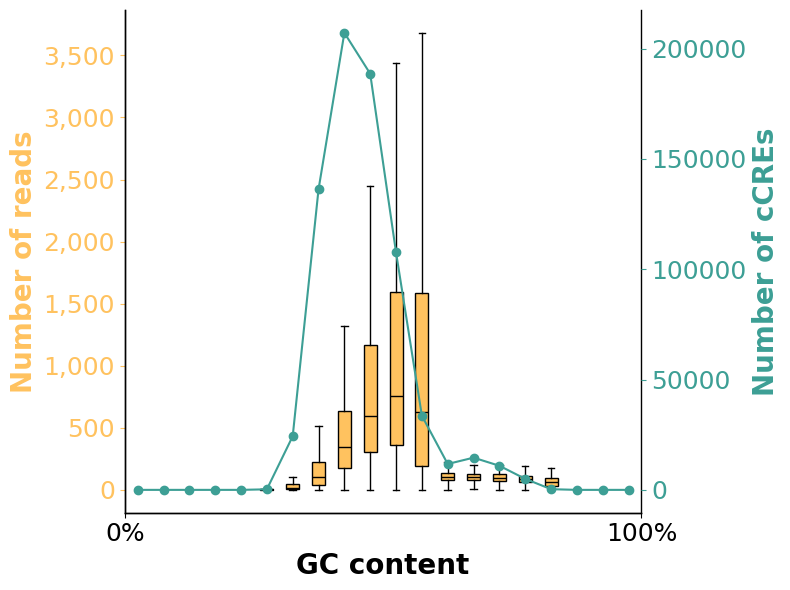

In [51]:
PCR_bias_GC_plot(final_counts_df)



## Produce RNA/DNA MAD score correlaiton fig

In [9]:
full_activity_df = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/quantitative_analysis_combined/comb_df_combined_fdr.csv')


/tmp/ipykernel_2734896/3656142334.py:1: DtypeWarning: Columns (55) have mixed types. Specify dtype option on import or set low_memory=False.
  full_activity_df = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/quantitative_analysis_combined/comb_df_combined_fdr.csv')


In [10]:
# Keep only rows where the 'oligo' column contains "SCREEN"
print(f"oligos before filtering for SCREEN overlap:{len(full_activity_df)}")
full_activity_df = full_activity_df[full_activity_df["oligo"].str.contains("SCREEN", na=False)]
print(f"oligos after filtering for SCREEN overlap:{len(full_activity_df)}")
full_activity_df =  full_activity_df[~full_activity_df["oligo"].str.contains("Ctrl", na=False)]
print(f"oligos after filtering for non-controls:{len(full_activity_df)}")

min_DNA_counts = 50
if min_DNA_counts>0:
    full_activity_df =  full_activity_df[(full_activity_df['DNA_rep_comb']>min_DNA_counts)]
    print(f"oligos after filtering for oligos with over 10 DNA counts (combined for all replicates):{len(full_activity_df)}")



# remove oligos which were later removed
full_activity_df = full_activity_df[~(full_activity_df['orientation_fix']=='fixed_in_L4')&
                           ~(full_activity_df['oligo'].str.contains('SCREEN_EH'))&
                          ~(full_activity_df['oligo'].str.contains('hh.missing.oligos')) ]
print(f"oligos after filtering out oligos which were later remoed due to L4a1 (eg orientation fix):{len(full_activity_df)}")

#if min_barcodes>0:
#    full_activity_df =  full_activity_df[(full_activity_df['bcs_DNA_rep1']>10) &(full_activity_df['bcs_DNA_rep2']>10)]
#    print(f"oligos after filtering for oligos with over 10 barcodesin both reps 1 and 2:{len(full_activity_df)}")


oligos before filtering for SCREEN overlap:740391
oligos after filtering for SCREEN overlap:713347
oligos after filtering for non-controls:712588
oligos after filtering for oligos with over 10 DNA counts (combined for all replicates):651533
oligos after filtering out oligos which were later remoed due to L4a1 (eg orientation fix):641797


In [11]:
full_activity_df

,oligo,RNA_chondrocytes_rep1,RNA_chondrocytes_rep2,RNA_chondrocytes_rep3,DNA_chondrocytes_rep1,DNA_chondrocytes_rep2,DNA_chondrocytes_rep3,statistic,control,zscore,...,max_UMI_RNA_rep3,max_UMI_DNA_rep3,fdr.mad_adjusted,activity_adjusted,input_comparative,coords,orientation_fix,fdr.mad_adjusted_combined,activity_adjusted_combined,input_comparative_combined
674,seq_13612_chr2:100859802-100860071_SCREEN_ance...,"[14.0, 9.0, 0.0, 0.0, 10.0, 0.0, 15.0, 1.0, 0....","[10.0, 2.0, 9.0, 0.0, 5.0, 21.0, 11.0, 0.0, 0....","[0.0, 14.0, 6.0, 3.0, 20.0, 20.0, 4.0, 7.0, 12...","[0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 7.0, 0.0, 0.0, ...","[4.0, 3.0, 0.0, 0.0, 3.0, 0.0, 2.0, 0.0, 0.0, ...","[0.0, 2.0, 0.0, 0.0, 0.0, 7.0, 12.0, 0.0, 0.0,...",1.558935,False,0.787798,...,21.0,13.0,0.374358,non_active,no,chr2:100859802-100860071,unchanged,0.417119,non_active,no
675,seq_13612_chr2:100859802-100860071_SCREEN_deri...,"[6.0, 6.0, 1.0, 2.0, 2.0, 0.0, 8.0, 3.0, 4.0, ...","[16.0, 3.0, 2.0, 5.0, 7.0, 6.0, 4.0, 2.0, 3.0,...","[12.0, 13.0, 0.0, 7.0, 17.0, 21.0, 13.0, 0.0, ...","[0.0, 0.0, 0.0, 5.0, 0.0, 0.0, 4.0, 5.0, 6.0, ...","[0.0, 4.0, 1.0, 6.0, 0.0, 4.0, 2.0, 0.0, 0.0, ...","[5.0, 0.0, 0.0, 5.0, 0.0, 6.0, 2.0, 0.0, 6.0, ...",1.426056,False,0.406208,...,21.0,14.0,0.493302,non_active,no,chr2:100859802-100860071,unchanged,0.563584,non_active,no
676,seq_13613_chr2:16958381-16958650_SCREEN_ancest...,"[0.0, 7.0, 0.0, 7.0, 2.0, 0.0, 10.0, 17.0, 16....","[8.0, 3.0, 5.0, 10.0, 1.0, 0.0, 11.0, 10.0, 3....","[5.0, 18.0, 0.0, 13.0, 2.0, 0.0, 10.0, 4.0, 12...","[3.0, 7.0, 2.0, 0.0, 0.0, 0.0, 8.0, 12.0, 3.0,...","[0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 5.0, ...","[0.0, 6.0, 0.0, 1.0, 0.0, 0.0, 1.0, 2.0, 0.0, ...",2.131752,False,2.432769,...,31.0,6.0,0.024377,active,yes,chr2:16958381-16958650,unchanged,0.015013,active,yes
677,seq_13613_chr2:16958381-16958650_SCREEN_derive...,"[1.0, 0.0, 1.0, 7.0, 3.0, 19.0, 5.0, 7.0, 14.0...","[6.0, 0.0, 1.0, 0.0, 5.0, 16.0, 14.0, 0.0, 12....","[0.0, 1.0, 1.0, 4.0, 4.0, 8.0, 7.0, 17.0, 0.0,...","[0.0, 0.0, 0.0, 2.0, 0.0, 1.0, 0.0, 0.0, 1.0, ...","[2.0, 0.0, 3.0, 0.0, 8.0, 2.0, 3.0, 0.0, 9.0, ...","[0.0, 5.0, 0.0, 0.0, 0.0, 1.0, 0.0, 5.0, 0.0, ...",1.316473,False,0.091517,...,17.0,32.0,0.595649,non_active,no,chr2:16958381-16958650,unchanged,0.665821,non_active,no
678,seq_13614_chr4:71048413-71048682_SCREEN_ancest...,"[17.0, 7.0, 7.0, 4.0, 0.0, 3.0, 3.0, 3.0, 6.0,...","[13.0, 0.0, 9.0, 0.0, 0.0, 1.0, 4.0, 0.0, 9.0,...","[5.0, 3.0, 0.0, 7.0, 43.0, 6.0, 0.0, 5.0, 6.0,...","[4.0, 0.0, 0.0, 0.0, 0.0, 3.0, 11.0, 0.0, 0.0,...","[0.0, 2.0, 5.0, 5.0, 0.0, 7.0, 0.0, 0.0, 2.0, ...","[2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.679981,False,1.135410,...,43.0,6.0,0.273149,non_active,no,chr4:71048413-71048682,unchanged,0.278248,non_active,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736111,seq_383185_chr9:130211279-130211548_SCREEN_der...,"[4.0, 0.0, 0.0, 2.0, 6.0, 1.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 3.0, 0.0, 1.0, ...","[3.0, 3.0, 0.0, 1.0, 2.0, 0.0, 0.0, 3.0, 3.0, ...","[0.0, 0.0, 0.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.637391,False,-0.559782,...,9.0,6.0,0.938942,non_active,no,chr9:130211279-130211548,unchanged,0.951657,non_active,no
736112,seq_383188_chrX:70475480-70475749_SCREEN_ances...,"[0.0, 0.0, 10.0, 0.0, 3.0, 0.0, 1.0, 1.0, 0.0,...","[0.0, 3.0, 6.0, 1.0, 1.0, 14.0, 0.0, 2.0, 0.0,...","[0.0, 0.0, 0.0, 8.0, 3.0, 0.0, 3.0, 3.0, 1.0, ...","[0.0, 0.0, 0.0, 12.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",0.796536,False,-0.328847,...,8.0,5.0,0.868489,non_active,no,chrX:70475480-70475749,unchanged,0.835837,non_active,no
736113,seq_383188_chrX:70475480-70475749_SCREEN_deriv...,"[6.0, 1.0, 0.0, 4.0, 1.0, 0.0, 0.0, 2.0, 0.0, ...","[6.0, 7.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.0, 7.0

/home/labs/davidgo/nadavmi/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


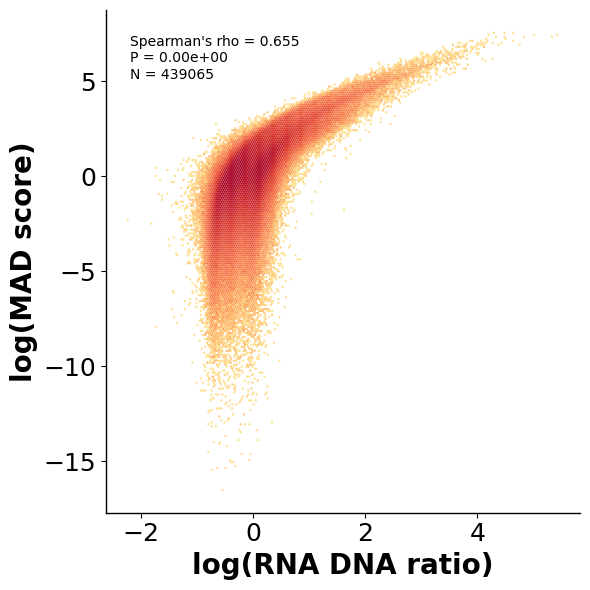

In [37]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


mask = full_activity_df["mad.score"]<200

x = full_activity_df["ratio_log_rep_comb"][mask]
y = np.log2(full_activity_df["mad.score"][mask])

valid = ~x.isna() & ~y.isna()
x = x[valid]
y = y[valid]

rho, pval = spearmanr(x, y)


fig, ax = plt.subplots(figsize=(6, 6))

# Hexbin density plot instead of scatter
hb = ax.hexbin(
    x, y,
    gridsize=200,              # tweak for smoother/coarser bins
    cmap=custom_cmap_bolder,  # same colormap as before
    mincnt=1,                 # only show bins with at least 1 point
    bins='log',                # log10 of counts
    linewidth = 0
)

# Dashed reference lines at x = 0 and y = 0
#ax.axhline(0, linestyle="--", linewidth=1)
#ax.axvline(0, linestyle="--", linewidth=1)

ax.set_xlabel("log(RNA DNA ratio)")
ax.set_ylabel("log(MAD score)")

# Add Spearman's rho and p-value to plot
ax.text(
    0.05, 0.95,
    f"Spearman's rho = {rho:.3f}\nP = {pval:.2e}\nN = {len(x)}",
    #f"Pearson r = {r:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left"
)

plt.tight_layout()

const.save_fig(plt, 'statistic_RNA_DNA_corr', output_path)

plt.show()

## Find specific oligos example

In [115]:
a3L3_df = full_activity_df[full_activity_df['oligo'].str.contains('_a3_L3')]
rep1_dna_sum = a3L3_df['DNA_rep1'].sum()
rep1_rna_sum = a3L3_df['RNA_rep1'].sum()

seq_name = 'seq_343252_chr1:32326432-32326701_SCREEN_ancestral_a3_L3'
a3L3_df = a3L3_df[a3L3_df['oligo'] == seq_name]


dna_count = (a3L3_df['DNA_rep1'].values[0]/rep1_dna_sum)*1_000_000
rna_count = (a3L3_df['RNA_rep1'].values[0]/rep1_rna_sum)*1_000_000

print(f"rep1: DNA count per million: {dna_count:.2f}, RNA count per million: {rna_count:.2f}")
print(rna_count/dna_count)
np.log2(rna_count/dna_count)

rep1: DNA count per million: 5.34, RNA count per million: 22.31
4.177423827968265


np.float64(2.062613522119057)

## Load RNA_DNA ratio df for L3a3

In [160]:
seq_name = 'seq_350395_chr5:67595471-67595740_SCREEN_derived_a3_L3'

In [161]:
ratio_df_L3a3 = pd.read_csv("/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes/L3a3/output/activity_after_filter/ratio_after_filter.csv")
ratio_df_L3a3 = ratio_df_L3a3[ratio_df_L3a3['oligo_column']==seq_name]

In [164]:
ratio_df_L3a3

,oligo_column,ratio_log_rep1,DNA_rep1,RNA_rep1,RNA_pseudo_rep1,DNA_pseudo_rep1,RNA_cpm_rep1,DNA_cpm_rep1,ratio_rep1,count_rep1,...,count_rep3,ratio_log_rep_comb,DNA_rep_comb,RNA_rep_comb,RNA_pseudo_rep_comb,DNA_pseudo_rep_comb,RNA_cpm_rep_comb,DNA_cpm_rep_comb,ratio_rep_comb,count_rep_comb
48228,seq_350395_chr5:67595471-67595740_SCREEN_deriv...,-0.738366,26.0,45.0,46.0,27.0,0.200391,0.33431,0.599418,17.0,...,19.0,1.118925,82.0,569.0,570.0,83.0,0.757934,0.348981,2.171851,25


In [162]:
a3L3_df = full_activity_df[full_activity_df['oligo'].str.contains('_a3_L3')]
a3L3_df = a3L3_df[a3L3_df['oligo'] == seq_name]

dna_count = (ratio_df_L3a3['DNA_rep1'].values[0]/rep1_dna_sum)*1_000_000
rna_count = (ratio_df_L3a3['RNA_rep1'].values[0]/rep1_rna_sum)*1_000_000



dna_count = ((dna_count)/rep1_dna_sum)*1_000_000
rna_count = ((rna_count)/rep1_rna_sum)*1_000_000

print(f"rep1: DNA count per million: {dna_count:.2f}, RNA count per million: {rna_count:.2f}")

rep1: DNA count per million: 0.14, RNA count per million: 0.03


In [165]:
a3L3_df

,oligo,RNA_chondrocytes_rep1,RNA_chondrocytes_rep2,RNA_chondrocytes_rep3,DNA_chondrocytes_rep1,DNA_chondrocytes_rep2,DNA_chondrocytes_rep3,statistic,control,zscore,...,max_UMI_RNA_rep3,max_UMI_DNA_rep3,fdr.mad_adjusted,activity_adjusted,input_comparative,coords,orientation_fix,fdr.mad_adjusted_combined,activity_adjusted_combined,input_comparative_combined
662530,seq_350395_chr5:67595471-67595740_SCREEN_deriv...,"[2.0, 3.0, 4.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, ...","[0.0, 5.0, 5.0, 0.0, 0.0, 2.0, 5.0, 2.0, 0.0, ...","[0.0, 0.0, 3.0, 0.0, 3.0, 0.0, 1.0, 2.0, 1.0, ...","[5.0, 0.0, 0.0, 0.0, 0.0, 2.0, 6.0, 0.0, 0.0, ...","[0.0, 0.0, 2.0, 0.0, 0.0, 5.0, 0.0, 4.0, 0.0, ...","[5.0, 1.0, 3.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, ...",1.394781,False,0.104322,...,4.0,5.0,0.817227,non_active,no,chr5:67595471-67595740,unchanged,0.58953,non_active,no


In [155]:
#filter for pval.mad>0.1 and then sort descending by ratio_log_rep1 #also only rows with a3_L3
query = full_activity_df[full_activity_df['pval.mad']>0.1]
query = query[query['oligo'].str.contains('_a3_L3')]
query = query[query['ratio_log_rep_comb']>1]

query = query.sort_values(by='ratio_log_rep1', ascending=False)